# Predicting NASDAQ Stock Direction with GRU
### Neural Networks & Deep Learning — Final Project 2025
#### Leo & Baris

Optiver Trading at the Close: Binary Prediction


## Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss, roc_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# light theme
sns.set_theme(style="whitegrid", font_scale=1.1)

interval_seconds = 10

#seeds
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## Load & Prepare Data

In [35]:
train = pd.read_csv("train.csv")
# remove rows with missing target values 
train = train.dropna(subset=["target"])
# create binary labels for targets greater than 0 (up) and less than or equal to 0 (down)
train["label"] = (train["target"] > 0).astype(int)


# Inspect dataset
print(f"Shape:          {train.shape}")
print(f"Stocks:         {train['stock_id'].nunique()}")
print(f"Trading dates:  {train['date_id'].nunique()}")
train.head()


Shape:          (5237892, 18)
Stocks:         200
Trading dates:  481


,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id,label
0,0,0,0,3180602.69,1,0.999812,13380276.64,NaN,NaN,0.999812,60651.50,1.000026,8493.03,1.0,-3.029704,0,0_0_0,0
1,1,0,0,166603.91,-1,0.999896,1642214.25,NaN,NaN,0.999896,3233.04,1.000660,20605.09,1.0,-5.519986,0,0_0_1,0
2,2,0,0,302879.87,-1,0.999561,1819368.03,NaN,NaN,0.999403,37956.00,1.000298,18995.00,1.0,-8.389950,0,0_0_2,0
3,3,0,0,11917682.27,-1,1.000171,18389745.62,NaN,NaN,0.999999,2324.90,1.000214,479032.40,1.0,-4.010200,0,0_0_3,0
4,4,0,0,447549.96,-1,0.999532,17860614.95,NaN,NaN,0.999394,16485.54,1.000016,434.10,1.0,-7.349849,0,0_0_4,0


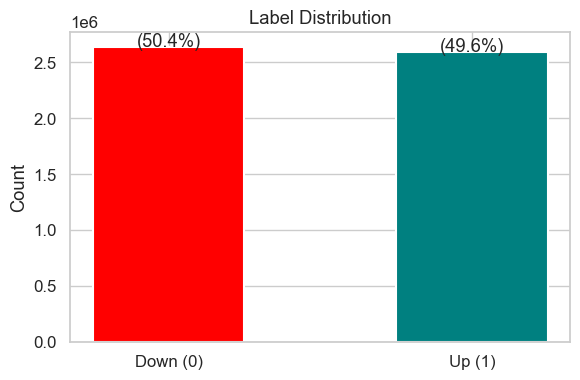

In [36]:
#Check label distribution
counts = train["label"].value_counts()
total  = len(train)

fig, ax = plt.subplots( figsize=(6, 4))

# create label bar chart
ax.bar(["Down (0)", "Up (1)"], counts.values,
            color=['red', 'teal'], linewidth=1.5, width=0.5)
ax.set_title("Label Distribution")
ax.set_ylabel("Count")
for i, j in enumerate(counts.values):
    ax.text(i, j + 2000, f"({j/total:.1%})",
                 ha="center")
plt.tight_layout()
plt.show()


## Preprocessing

In [37]:
def group_time_intervals(df, interval_seconds):
    df = df.copy()
    # create time groups by bucketing seconds_in_bucket into intervals
    df["time_group"] = (df["seconds_in_bucket"] // interval_seconds) * interval_seconds
    return df.groupby(["stock_id", "date_id", "time_group"], as_index=False).agg({
        "seconds_in_bucket": "last",
        "imbalance_size": "mean",
        "imbalance_buy_sell_flag": "last",
        "reference_price": "last",
        "matched_size": "mean",
        "far_price":  "last",
        "near_price": "last",
        "bid_price": "last",
        "bid_size": "mean",
        "ask_price": "last",
        "ask_size": "mean",
        "wap": "last",
        "target": "last",
        "label": "last",
    })

train = group_time_intervals(train, interval_seconds)

#  engineering features that'd be useful from online discussions and domain knowledge
train["bid_ask_spread"] = train["ask_price"] - train["bid_price"]
train["mid_price"] = (train["ask_price"] + train["bid_price"]) / 2
train["imbalance_ratio"] = train["imbalance_size"] / (train["matched_size"] + 1)
train["wap_reference_diff"] = train["wap"] - train["reference_price"]
train["wap_mid_diff"] = train["wap"] - train["mid_price"]
train["size_ratio"] = train["bid_size"] / (train["ask_size"] + 1)
train["matched_imbalance_ratio"] = train["matched_size"] / (train["imbalance_size"] + 1)

# Rolling / lag features
def add_sequence_features(df):
    df = df.sort_values(["stock_id", "date_id", "seconds_in_bucket"]).copy()
    grp = df.groupby(["stock_id", "date_id"])
    df["wap_lag1"] = grp["wap"].shift(1)
    df["wap_return"]  = df["wap"] / (df["wap_lag1"].replace(0, np.nan) + 1e-8) - 1
    df["imbalance_roll3"] = grp["imbalance_ratio"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df["spread_roll3"] = grp["bid_ask_spread"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df["wap_roll_std"] = grp["wap"].transform(lambda x: x.rolling(5, min_periods=1).std())
    return df.fillna(0)

train = add_sequence_features(train)

features = [
    "seconds_in_bucket",
    "imbalance_size", "imbalance_buy_sell_flag",
    "reference_price", "matched_size",
    "far_price", "near_price",
    "bid_price", "bid_size", "ask_price", "ask_size", "wap",
    "bid_ask_spread", "mid_price",
    "imbalance_ratio", "wap_reference_diff", "wap_mid_diff",
    "size_ratio", "matched_imbalance_ratio",
    "wap_return", "imbalance_roll3", "spread_roll3", "wap_roll_std",
]
train[features] = train[features].replace([np.inf, -np.inf], np.nan).fillna(0)


## Train / Validation Split & DataLoader

In [38]:
seq_map = {10: 55, 30: 19, 60: 10, 120: 5}
seq_len = seq_map[interval_seconds]

unique_dates = sorted(train["date_id"].unique())
split_idx = int(0.8 * len(unique_dates))
train_df = train[train["date_id"].isin(unique_dates[:split_idx])].copy()
val_df = train[train["date_id"].isin(unique_dates[split_idx:])].copy()

scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
val_df[features]   = scaler.transform(val_df[features])

print(f"Seq length is {seq_len} steps")


Seq length is 55 steps


In [39]:
# custom dataset to create sequences of features for each stock_id and date_id
class StockDataset(Dataset):
    def __init__(self, df):
        X_list, y_list = [], []
        for _, g in df.groupby(["stock_id", "date_id"]):
            g = g.sort_values("seconds_in_bucket")
            if len(g) == seq_len:
                X_list.append(g[features].values)
                y_list.append(g["label"].iloc[-1])
        self.X = torch.tensor(np.array(X_list), dtype=torch.float32)
        self.y = torch.tensor(np.array(y_list), dtype=torch.long)

    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# create DataLoaders for training and validation
batch_size = 64
train_dataset = StockDataset(train_df)
val_dataset = StockDataset(val_df)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Tensor shape — X: {train_dataset.X.shape}  y: {train_dataset.y.shape}")


Tensor shape — X: torch.Size([75834, 55, 23])  y: torch.Size([75834])


## GRU Model

In [40]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2),
        )

    def forward(self, x):
        _, hidden = self.gru(x)
        return self.head(hidden[-1])


## Hyperparameters


In [41]:
hidden_size=64
num_layers=3
dropout=0.3
epochs = 10
lr = 0.001
weight_decay = 0.01

## Model Training

In [42]:
# initialize model
model = GRUModel(
    input_size=len(features),
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

label_counts  = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor(
    [1.0 / label_counts[0], 1.0 / label_counts[1]], dtype=torch.float32
).to(device)
class_weights /= class_weights.sum()

# define loss function and optimizer
loss_fn   = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# create learning rate scheduler 
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=lr, epochs=epochs,
    steps_per_epoch=len(train_loader), pct_start=0.3, anneal_strategy="cos",
)

# 
tracking = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

# training loop
for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        loss = loss_fn(model(X_batch), y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

# evaluate on validation set
# we cannot use test.csv for evaluating accuracy as there is
# no target column, which means there's no ground truth to compare your predictions against.
# so we'd have no way to know if your predictions were right or wrong if we used it.
# The target is exactly what the Kaggle competition asks you to predict.

    model.eval()
    total_val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_val_loss += loss_fn(logits, y_batch).item()
            all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    tracking["train_loss"].append(total_train_loss / len(train_loader))
    tracking["val_loss"].append(total_val_loss / len(val_loader))
    tracking["val_acc"].append(accuracy_score(all_labels, all_preds))
    tracking["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"Epoch {epoch:2d}/{epochs} | "
          f"Train Loss: {tracking['train_loss'][-1]:.4f} "
          f"Val Loss: {tracking['val_loss'][-1]:.4f} "
          f"Val Acc: {tracking['val_acc'][-1]:.4f}")


Epoch  1/10 | Train Loss: 0.6865 Val Loss: 0.6582 Val Acc: 0.6146
Epoch  2/10 | Train Loss: 0.6677 Val Loss: 0.6573 Val Acc: 0.6095
Epoch  3/10 | Train Loss: 0.6645 Val Loss: 0.6544 Val Acc: 0.6155
Epoch  4/10 | Train Loss: 0.6622 Val Loss: 0.6541 Val Acc: 0.6234
Epoch  5/10 | Train Loss: 0.6596 Val Loss: 0.6478 Val Acc: 0.6259
Epoch  6/10 | Train Loss: 0.6574 Val Loss: 0.6501 Val Acc: 0.6165
Epoch  7/10 | Train Loss: 0.6551 Val Loss: 0.6465 Val Acc: 0.6260
Epoch  8/10 | Train Loss: 0.6534 Val Loss: 0.6473 Val Acc: 0.6222
Epoch  9/10 | Train Loss: 0.6518 Val Loss: 0.6455 Val Acc: 0.6267
Epoch 10/10 | Train Loss: 0.6500 Val Loss: 0.6453 Val Acc: 0.6265


## Results

In [43]:
model.eval()
final_preds, final_labels, final_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch.to(device))
        final_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        final_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        final_labels.extend(y_batch.numpy())

acc = accuracy_score(final_labels, final_preds)
auc = roc_auc_score(final_labels, final_probs)
ll = log_loss(final_labels, final_probs)

print(f"Validation Accuracy : {acc:.4f}")
print(f"AUC-ROC : {auc:.4f}")
print(f"Log Loss : {ll:.4f}")
print(classification_report(final_labels, final_preds, target_names=["Down (0)", "Up (1)"]))


Validation Accuracy : 0.6265
AUC-ROC : 0.6740
Log Loss : 0.6448
              precision    recall  f1-score   support

    Down (0)       0.63      0.65      0.64      9847
      Up (1)       0.63      0.60      0.61      9551

    accuracy                           0.63     19398
   macro avg       0.63      0.63      0.63     19398
weighted avg       0.63      0.63      0.63     19398



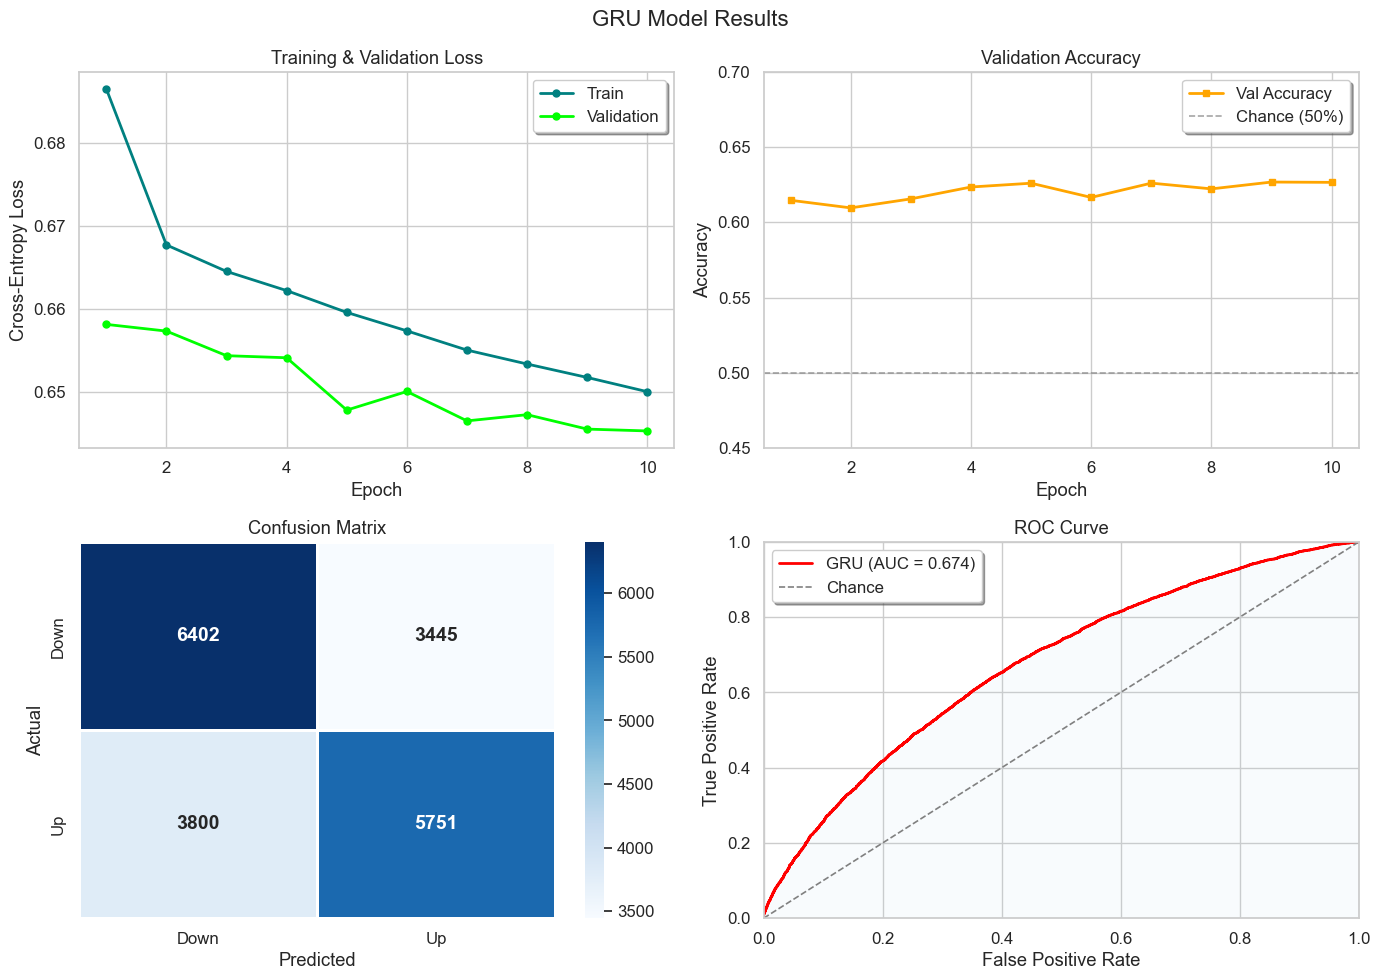

In [44]:
from sklearn.metrics import roc_curve

epochs_x = range(1, epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train vs Val Loss Plot
axes[0,0].plot(epochs_x, tracking["train_loss"], color='teal', lw=2, marker="o", ms=5, label="Train")
axes[0,0].plot(epochs_x, tracking["val_loss"],   color='lime', lw=2, marker="o", ms=5, label="Validation")
axes[0,0].set_title("Training & Validation Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Cross-Entropy Loss")
axes[0,0].legend(shadow=True)

# Validation Accuracy Plot
axes[0,1].plot(epochs_x, tracking["val_acc"], color='orange', lw=2, marker="s", ms=5, label="Val Accuracy")
axes[0,1].axhline(0.5, color='gray', lw=1.2, linestyle="--", alpha=0.7, label="Chance (50%)")
axes[0,1].set_ylim(0.45, 0.70)
axes[0,1].set_title("Validation Accuracy")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend(shadow=True)

# Confusion Matrix plot
cm = confusion_matrix(final_labels, final_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"],
            yticklabels=["Down", "Up"],
            ax=axes[1, 0],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
axes[1,0].set_title("Confusion Matrix")
axes[1,0].set_xlabel("Predicted")
axes[1,0].set_ylabel("Actual")

# ROC Curve plot
fpr, tpr, _ = roc_curve(final_labels, final_probs)
axes[1,1].plot(fpr, tpr, color='red', lw=2, label=f"GRU (AUC = {auc:.3f})")
axes[1,1].plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle="--", label="Chance")
axes[1,1].fill_between(fpr, tpr, alpha=0.08, color='lightblue')
axes[1,1].set_title("ROC Curve")
axes[1,1].set_xlabel("False Positive Rate")
axes[1,1].set_ylabel("True Positive Rate")
axes[1,1].legend(shadow=True)
axes[1,1].set_xlim([0, 1])
axes[1,1].set_ylim([0, 1])

plt.suptitle("GRU Model Results", fontsize=16)
plt.tight_layout()
plt.show()


Findings are that while aining and validation accurcy imporve with increasing epoch number it is very hard to improve upon inital accuracy gained from sequetional patterns as something this volatile can easily be overfitted but we do get above a 50% change as seen from our ROC curve and Confusion Matrix. For future endeavors it would be ideal to experiment with transfomrer model to see if we can increase our testing accuracy. This would need more reading of literature on these types of more complex models.